In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

data = pd.read_csv("data.csv")

# reduce size for speed
data = data.sample(5000, random_state=42)

print(data.head())

            FILENAME                                                URL  \
136221    827598.txt                          https://www.northcm.ac.th   
56609   oph00308.txt  https://unitedmartialartscenters.com/at0/mygov...   
46393    8112660.txt  https://email.mail1.onesignal.os.tc/c/ejwcz02u...   
129746   8135291.txt                                http://uqr.to/1il1z   
131464    586561.txt               https://www.woolworthsrewards.com.au   

        URLLength                        Domain  DomainLength  IsDomainIP  \
136221         24             www.northcm.ac.th            17           0   
56609          59  unitedmartialartscenters.com            28           0   
46393         385   email.mail1.onesignal.os.tc            27           0   
129746         19                        uqr.to             6           0   
131464         35  www.woolworthsrewards.com.au            28           0   

        TLD  URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  \
13622

In [2]:
print("Shape:", data.shape)
print("Missing:", data.isnull().sum().sum())

Shape: (5000, 56)
Missing: 0


In [3]:
# Use only 1 feature (IMPORTANT)
X = data[['URLLength']]   # you can change column if needed
y = data['label']

print("Using single feature for polynomial regression")

Using single feature for polynomial regression


In [4]:
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

degrees = [1, 2, 3, 4]
mse_list = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

    print(f"Degree {d} → MSE: {mse}")

Degree 1 → MSE: 0.22800282424726484
Degree 2 → MSE: 0.2058149952043568
Degree 3 → MSE: 0.19553520979216446
Degree 4 → MSE: 0.19489630701652796


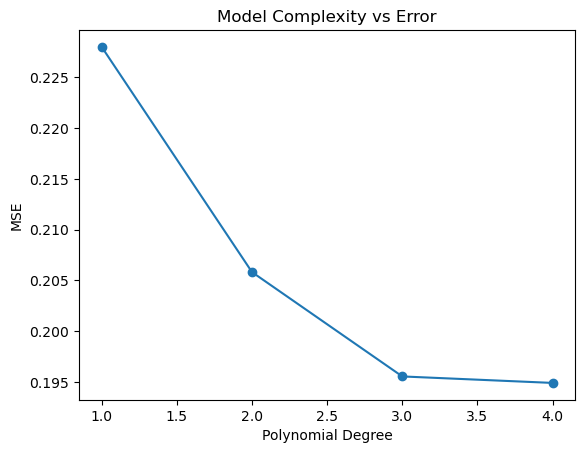

In [5]:
plt.plot(degrees, mse_list, marker='o')
plt.title("Model Complexity vs Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.show()